# IoTSpy — Traffic EDA (Sample)

Exploratory analysis of IoT device traffic captured via the IoTSpy explicit proxy.

**Prerequisites:** run `00_generate_sample_data.ipynb` first to create `../data/sample_captures.parquet`,
or point `DATA_PATH` at a Parquet file produced by `analytics/scripts/extract_features.py`.

Key questions:
- Which hosts do devices contact, and how often?
- What fraction of traffic goes to known ad/tracking networks?
- What do temporal burst patterns look like per device?
- What is the TLS posture of the traffic?
- What risk labels did the rule engine assign?

In [1]:
from pathlib import Path
import json
from collections import Counter
from itertools import chain

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

# ── Point this at the Parquet from 00_generate_sample_data or extract_features.py ──
DATA_PATH = Path("../data/sample_captures.parquet")
BROKER_LIST = Path("../../data/data_broker_domains.txt")

assert DATA_PATH.exists(), f"Run 00_generate_sample_data.ipynb first (expected: {DATA_PATH.resolve()})"

df = pd.read_parquet(DATA_PATH)
if "timestamp" not in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp_ms"], unit="ms", utc=True)
if "tags" not in df.columns:
    df["tags"] = "[]"
df["tag_list"] = df["tags"].apply(json.loads)

print(f"{len(df):,} captures | {df['host'].nunique()} unique hosts | "
      f"{df['timestamp'].max() - df['timestamp'].min()} session duration")
if "device_name" in df.columns:
    print(f"Devices: {sorted(df['device_name'].unique())}")

2,200 captures | 23 unique hosts | 0 days 01:59:50.438000 session duration
Devices: ['game-console', 'security-camera', 'smart-tv', 'voice-assistant']


## 1  Load broker domain list

In [2]:
broker_domains: set[str] = set()
if BROKER_LIST.exists():
    for line in BROKER_LIST.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#"):
            broker_domains.add(line.lower())

def is_broker_domain(host: str) -> bool:
    h = (host or "").lower()
    return any(h == d or h.endswith("." + d) for d in broker_domains)

# Use ground-truth column when available (synthetic data), fall back to domain list
if "is_known_broker" in df.columns:
    df["is_broker"] = df["is_known_broker"].astype(bool)
else:
    df["is_broker"] = df["host"].apply(is_broker_domain)

print(f"Broker traffic: {df['is_broker'].sum():,}  ({df['is_broker'].mean()*100:.1f}%)")

Broker traffic: 1,298  (59.0%)


## 2  Top hosts

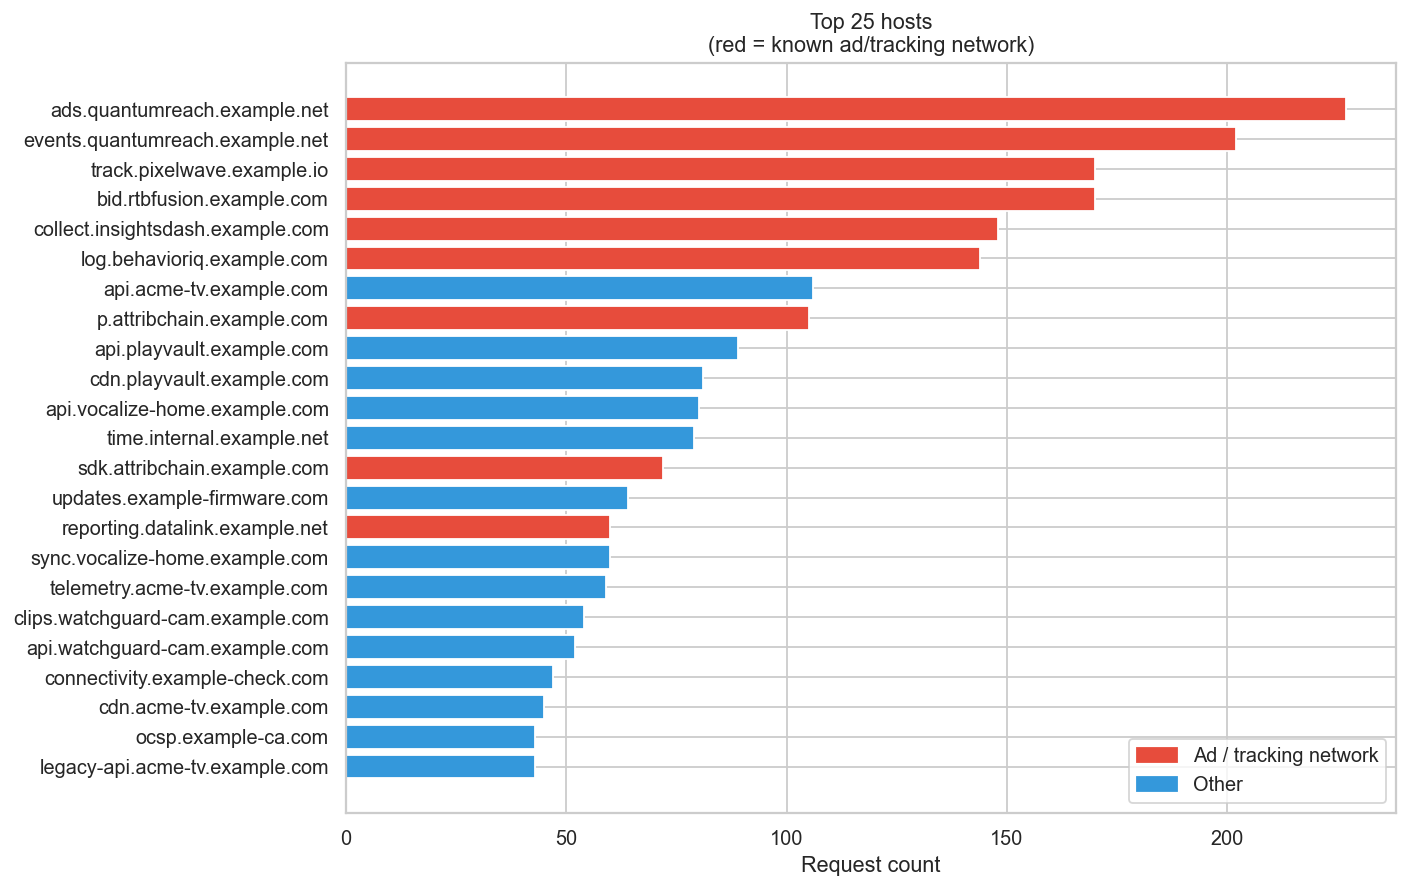

In [3]:
top_hosts = (
    df.groupby("host")
    .agg(count=("capture_id", "size"), is_broker=("is_broker", "first"))
    .sort_values("count", ascending=False)
    .head(25)
    .reset_index()
)

colors = ["#e74c3c" if b else "#3498db" for b in top_hosts["is_broker"]]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top_hosts["host"][::-1], top_hosts["count"][::-1], color=colors[::-1])
ax.set_xlabel("Request count")
ax.set_title("Top 25 hosts\n(red = known ad/tracking network)")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#e74c3c", label="Ad / tracking network"),
    Patch(color="#3498db", label="Other"),
])
plt.tight_layout()
plt.show()

## 3  Per-device traffic volume

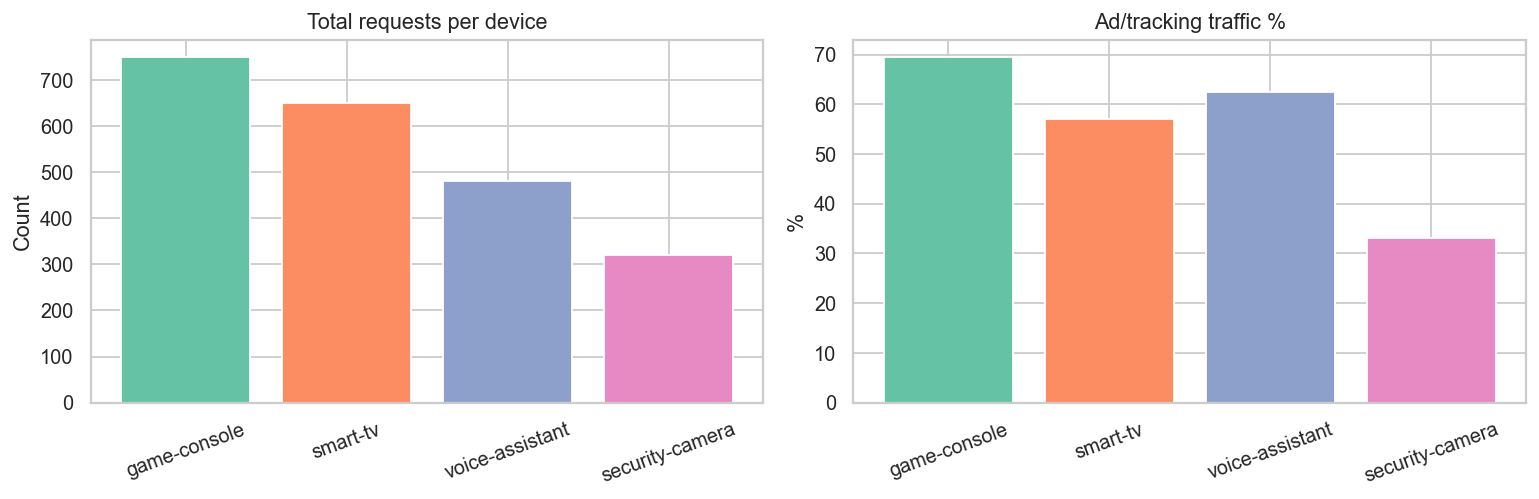

    device_name  total  broker_pct  unique_hosts
   game-console    750        69.5            16
       smart-tv    650        57.1            17
voice-assistant    480        62.5            15
security-camera    320        33.1            16


In [4]:
group_col = "device_name" if "device_name" in df.columns else "client_ip"

device_summary = (
    df.groupby(group_col)
    .agg(
        total=("capture_id", "size"),
        broker_pct=("is_broker", "mean"),
        unique_hosts=("host", "nunique"),
    )
    .reset_index()
    .sort_values("total", ascending=False)
)
device_summary["broker_pct"] = (device_summary["broker_pct"] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(device_summary[group_col], device_summary["total"],
            color=sns.color_palette("Set2", len(device_summary)))
axes[0].set_title("Total requests per device")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(device_summary[group_col], device_summary["broker_pct"],
            color=sns.color_palette("Set2", len(device_summary)))
axes[1].set_title("Ad/tracking traffic %")
axes[1].set_ylabel("%")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()
print(device_summary.to_string(index=False))

## 4  Temporal burst analysis

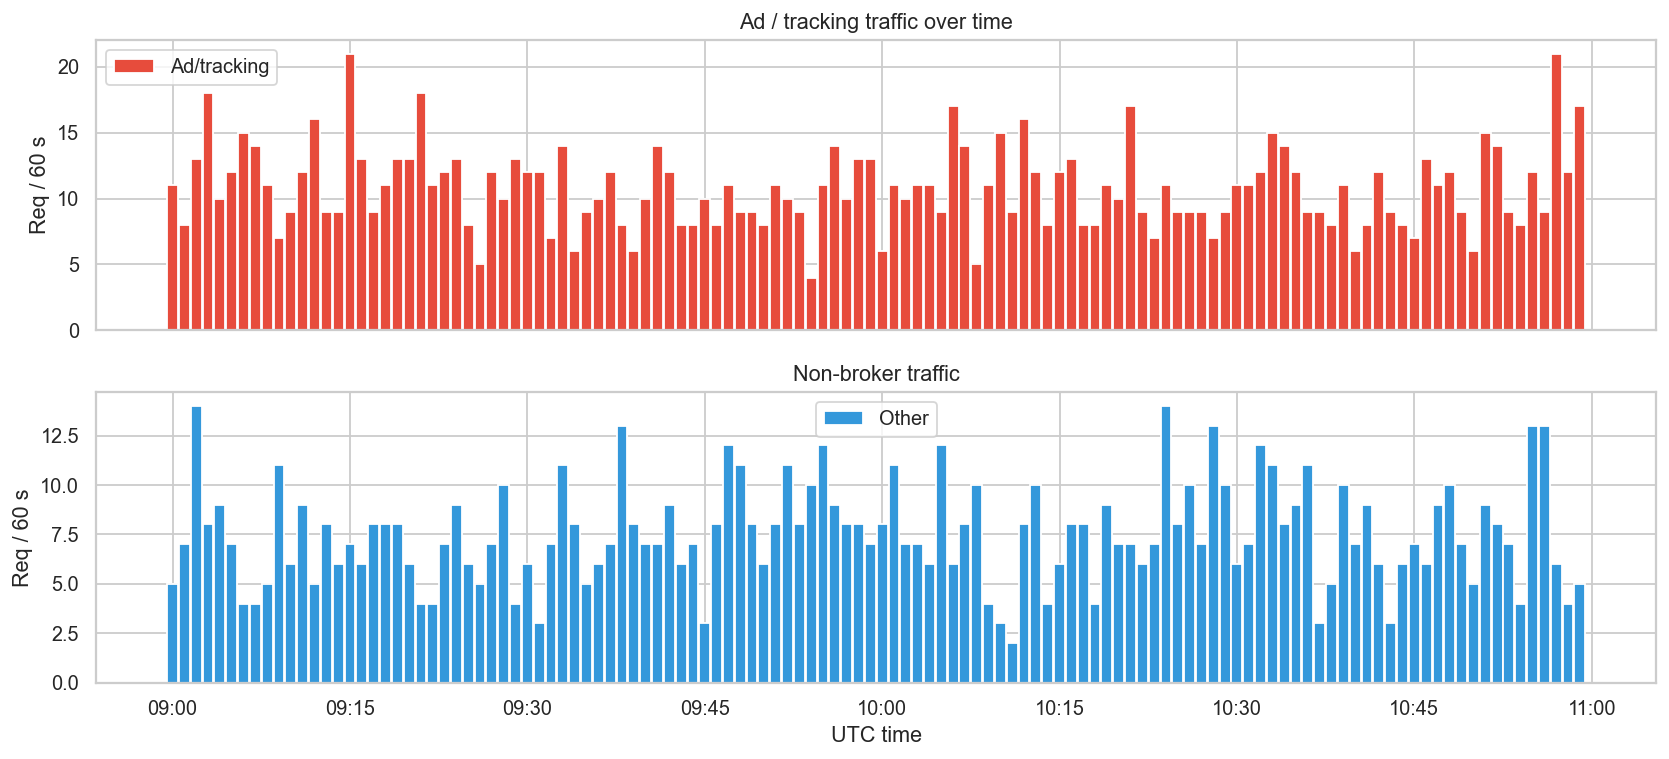

In [5]:
df["bucket"] = df["timestamp"].dt.floor("60s")

timeline = (
    df.groupby(["bucket", "is_broker"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={False: "other", True: "broker"})
)

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].bar(timeline.index, timeline.get("broker", 0),
            width=pd.Timedelta("55s"), color="#e74c3c", label="Ad/tracking")
axes[0].set_ylabel("Req / 60 s")
axes[0].set_title("Ad / tracking traffic over time")
axes[0].legend()

axes[1].bar(timeline.index, timeline.get("other", 0),
            width=pd.Timedelta("55s"), color="#3498db", label="Other")
axes[1].set_ylabel("Req / 60 s")
axes[1].set_title("Non-broker traffic")
axes[1].legend()

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xlabel("UTC time")
plt.tight_layout()
plt.show()

## 5  TLS posture

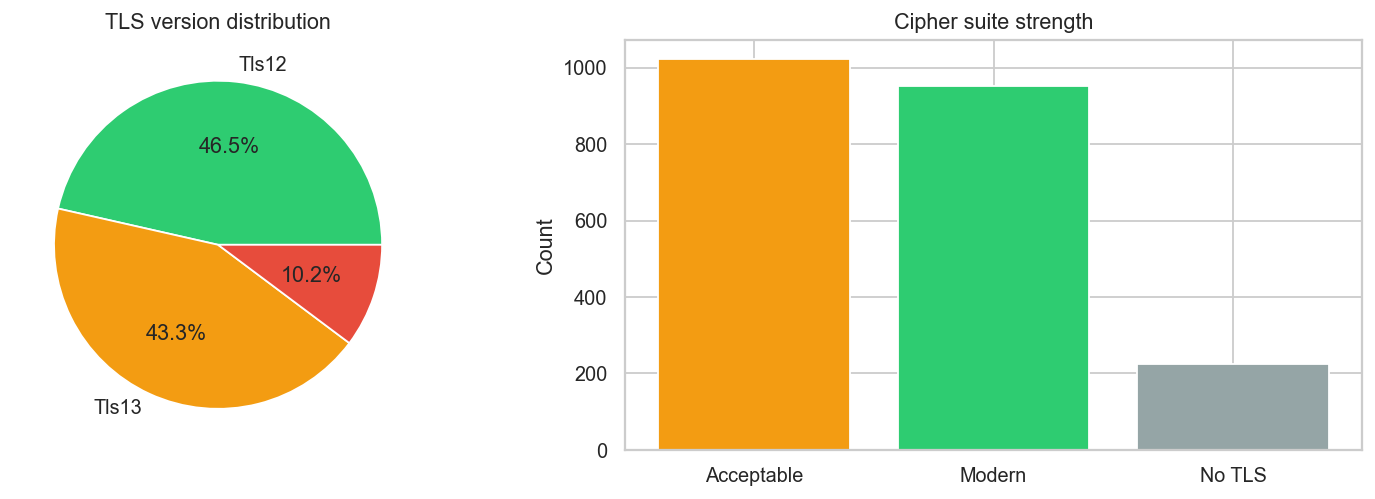

Plaintext HTTP requests: 225  (10.2%)


In [6]:
WEAK_CIPHERS   = {"rc4", "3des", "des", "null", "export", "anon"}
MODERN_CIPHERS = {"tls_aes_128_gcm", "tls_aes_256_gcm", "chacha20",
                  "ecdhe_rsa_aes_128_gcm", "ecdhe_rsa_aes_256_gcm"}

def cipher_label(c):
    if not c: return "No TLS"
    lc = c.lower()
    if any(w in lc for w in WEAK_CIPHERS):   return "Weak"
    if any(m in lc for m in MODERN_CIPHERS): return "Modern"
    return "Acceptable"

cipher_col = "tls_cipher_suite" if "tls_cipher_suite" in df.columns else "TlsCipherSuite"
tls_ver_col = "tls_version" if "tls_version" in df.columns else "TlsVersion"

df["cipher_label"] = df[cipher_col].apply(cipher_label)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tls_v = df[tls_ver_col].fillna("None").value_counts()
axes[0].pie(tls_v, labels=tls_v.index, autopct="%1.1f%%",
            colors=["#2ecc71", "#f39c12", "#e74c3c", "#95a5a6"][:len(tls_v)])
axes[0].set_title("TLS version distribution")

cipher_c = df["cipher_label"].value_counts()
palette = {"Modern": "#2ecc71", "Acceptable": "#f39c12", "Weak": "#e74c3c", "No TLS": "#95a5a6"}
axes[1].bar(cipher_c.index, cipher_c.values,
            color=[palette.get(l, "#95a5a6") for l in cipher_c.index])
axes[1].set_title("Cipher suite strength")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

plaintext = (df[cipher_col].isna() | (df[cipher_col] == "")).sum()
print(f"Plaintext HTTP requests: {plaintext:,}  ({plaintext/len(df)*100:.1f}%)")

## 6  Payload size distributions

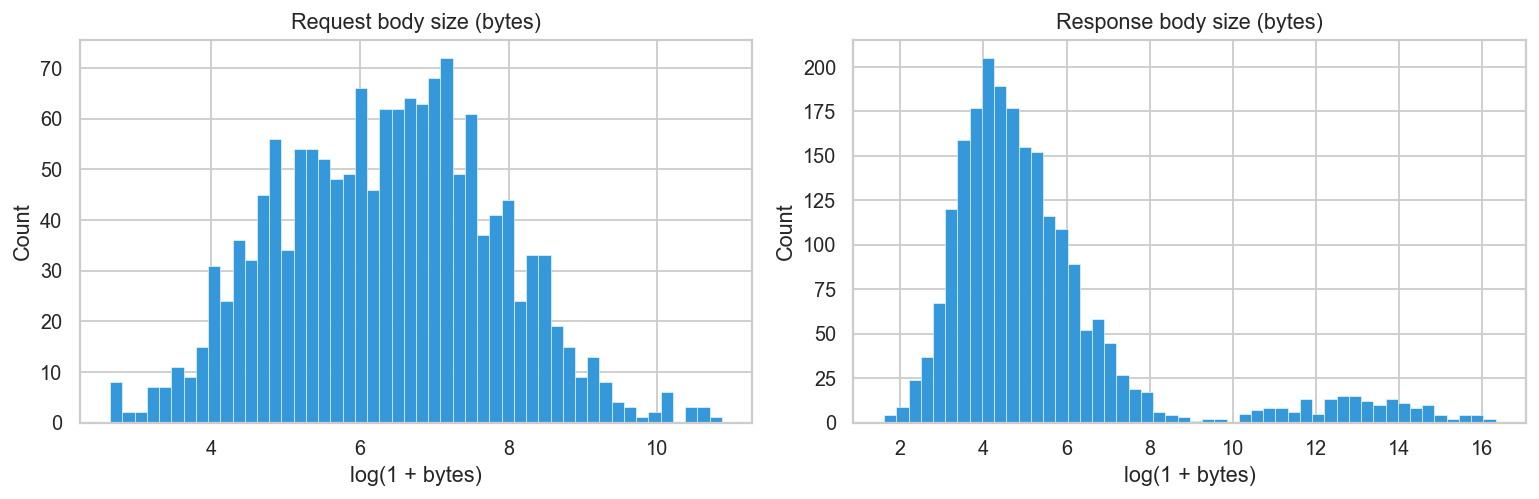

In [7]:
req_col  = "request_body_size"  if "request_body_size"  in df.columns else "RequestBodySize"
resp_col = "response_body_size" if "response_body_size" in df.columns else "ResponseBodySize"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in [
    (axes[0], req_col,  "Request body size (bytes)"),
    (axes[1], resp_col, "Response body size (bytes)"),
]:
    data = df[df[col] > 0][col]
    ax.hist(np.log1p(data), bins=50, color="#3498db", edgecolor="white", linewidth=0.3)
    ax.set_xlabel(f"log(1 + bytes)")
    ax.set_title(label)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 7  Rule-based risk insight tags

Tag distribution: {'DataBroker': 1298, 'PiiDetected': 93, 'ExfiltrationRisk': 46}


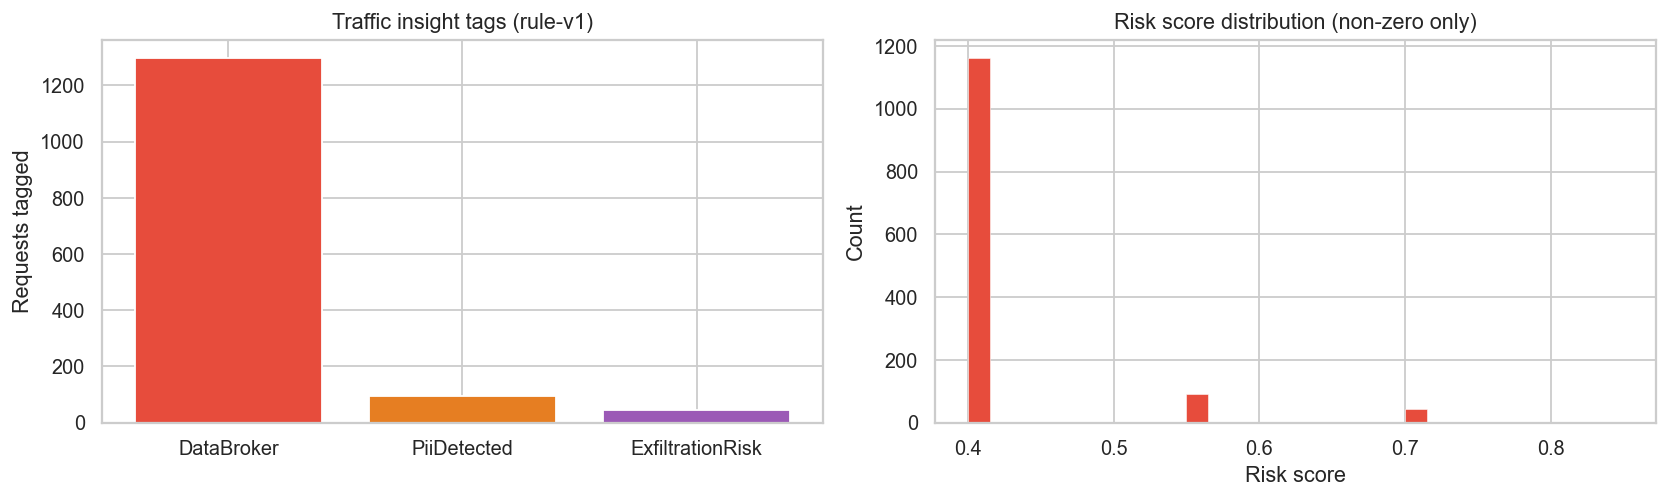


Max risk score:   0.8500
Rows with risk>0: 1,298  (59.0%)


In [8]:
tag_counts = Counter(chain.from_iterable(df["tag_list"]))
risk_col   = "risk_score" if "risk_score" in df.columns else "RiskScore"

print("Tag distribution:", dict(tag_counts))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

if tag_counts:
    tag_df = pd.DataFrame(tag_counts.items(), columns=["tag", "count"]).sort_values("count", ascending=False)
    axes[0].bar(tag_df["tag"], tag_df["count"],
                color=["#e74c3c", "#e67e22", "#9b59b6"][:len(tag_df)])
    axes[0].set_title("Traffic insight tags (rule-v1)")
    axes[0].set_ylabel("Requests tagged")

risk_scores = df[risk_col].fillna(0)
axes[1].hist(risk_scores[risk_scores > 0], bins=30, color="#e74c3c", edgecolor="white", lw=0.3)
axes[1].set_title("Risk score distribution (non-zero only)")
axes[1].set_xlabel("Risk score")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"\nMax risk score:   {risk_scores.max():.4f}")
print(f"Rows with risk>0: {(risk_scores > 0).sum():,}  ({(risk_scores > 0).mean()*100:.1f}%)")

## 8  Summary

In [9]:
print("=" * 58)
print("TRAFFIC EDA SUMMARY")
print("=" * 58)
print(f"Total captures:       {len(df):>8,}")
print(f"Unique hosts:         {df['host'].nunique():>8,}")
print(f"Devices / source IPs: {df['client_ip'].nunique():>8,}")
print(f"Session duration:     {df['timestamp'].max() - df['timestamp'].min()}")
print()
print(f"Ad/tracking traffic:  {df['is_broker'].sum():>8,}  ({df['is_broker'].mean()*100:.1f}%)")
print(f"Plaintext HTTP:       {(df[cipher_col].isna() | (df[cipher_col]=='')).sum():>8,}")
print()
print("Rule-v1 tags:")
for tag, cnt in sorted(tag_counts.items(), key=lambda x: -x[1]):
    print(f"  {tag:<22} {cnt:>6,}  ({cnt/len(df)*100:.1f}%)")
print("=" * 58)

TRAFFIC EDA SUMMARY
Total captures:          2,200
Unique hosts:               23
Devices / source IPs:        4
Session duration:     0 days 01:59:50.438000

Ad/tracking traffic:     1,298  (59.0%)
Plaintext HTTP:            225

Rule-v1 tags:
  DataBroker              1,298  (59.0%)
  PiiDetected                93  (4.2%)
  ExfiltrationRisk           46  (2.1%)
